## 4I. For each change of mind episode (outer arm visit) with remote events, find the distribution of 
- the length of each event
- delta t between remote representations of the same arm, of different arms, or either.

In [1]:
%load_ext autoreload
%autoreload 2

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from spyglass.shijiegu.Analysis_SGU import ChangeofMindRemoteTheta
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.changeOfMind_figures.supp_remote_length import return_concentration_day
from spyglass.shijiegu.changeOfMind import color_by_rat

[19:35:42][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[19:35:42][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


In [3]:
list_of_days_animals = {}
encoding_set_animals = {}
classifier_param_name_animals = {}
seq_animals = {}
success_animal = {}

animal = 'eliot'
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
encoding_set_animals[animal] = '2Dheadspeed_above_4_andlowmua'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'seq2'

animal = 'molly'
list_of_days_animals[animal] = ['20220416','20220417','20220418','20220419','20220420']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110','20240113','20240114']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'rev2'

animal = "julio"
list_of_days_animals[animal] = ['20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

animal = "klein"
list_of_days_animals[animal] = ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107','20231108','20231109','20231111']
seq_animals[animal] = 'rev2'
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

In [18]:
remote_length, delta_ts_same, delta_ts_diff, delta_ts_all = {}, {}, {}, {}

for animal in list_of_days_animals.keys():
    days = list_of_days_animals[animal]
    (remote_length[animal], delta_ts_same[animal],
     delta_ts_diff[animal], delta_ts_all[animal]) = return_concentration_day(animal, days)

Processing eliot 20221018 session: 02_Seq2Session1 for remote length
Processing eliot 20221018 session: 04_Seq2Session2 for remote length
Processing eliot 20221018 session: 05_Seq2Session3 for remote length
Processing eliot 20221018 session: 07_Seq2Session4 for remote length
Processing eliot 20221018 session: 09_Seq2Session5 for remote length
Processing eliot 20221018 session: 11_Seq2Session6 for remote length
Processing eliot 20221019 session: 02_Seq2Session1 for remote length
Processing eliot 20221019 session: 04_Seq2Session2 for remote length
Processing eliot 20221019 session: 06_Seq2Session3 for remote length
Processing eliot 20221019 session: 08_Seq2Session4 for remote length
Processing eliot 20221019 session: 10_Seq2Session5 for remote length
Processing eliot 20221020 session: 02_Seq2Session1 for remote length
Processing eliot 20221020 session: 04_Seq2Session2 for remote length
Processing eliot 20221020 session: 06_Seq2Session3 for remote length
Processing eliot 20221020 session:

### (0) print stats

In [50]:
for animal in ["eliot","lewis","molly","julio","klein"]:

    plot_data = np.array(remote_length[animal])
    print(f"Rat {animal[0].upper()}")
    print(f"The means are {np.round(np.mean(plot_data),3)}, 95% interval: ({np.round(np.quantile(plot_data, 0.025),3)}, {np.round(np.quantile(plot_data, 1-0.025),3)})")

Rat E
The means are 0.07, 95% interval: (0.022, 0.227)
Rat L
The means are 0.056, 95% interval: (0.022, 0.133)
Rat M
The means are 0.041, 95% interval: (0.022, 0.096)
Rat J
The means are 0.067, 95% interval: (0.022, 0.167)
Rat K
The means are 0.067, 95% interval: (0.022, 0.23)


### (1) Event length

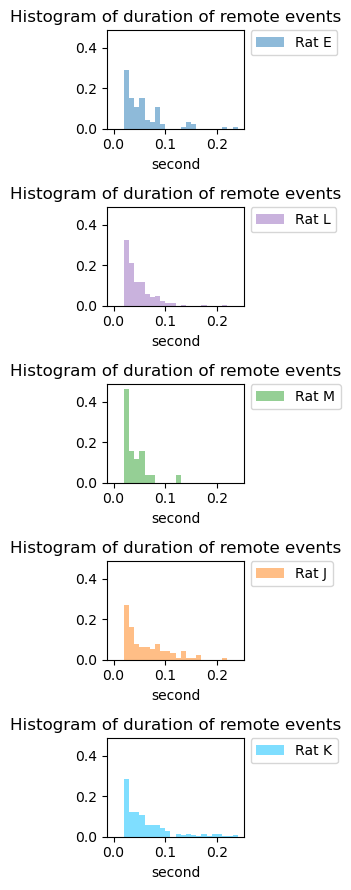

In [36]:
fig, axes = plt.subplots(5, 1, figsize=(3, 9),sharey = True)

ind = 0
for animal in ["eliot","lewis","molly","julio","klein"]:

    plot_data = np.array(remote_length[animal])
    plot_data = plot_data[plot_data > 0]
    axes[ind].hist(plot_data,
             weights = np.ones_like(plot_data)/len(plot_data),
             bins = np.arange(0,0.25,0.01),
             alpha = 0.5,
             label = f"Rat {animal[0].upper()}",
              color = color_by_rat[animal]
             )
    
    #axes.set_xticks(np.array([1,2,3]) + 0.5)
    #axes.set_xticklabels(np.array([1,2,3]))
    #axes.set_xlim([0.8,4.2])
    
    axes[ind].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    axes[ind].set_xlabel("second")
    axes[ind].set_title(f"Histogram of duration of remote events")

    ind += 1

plt.tight_layout()
plt.savefig(f'4L.remote_content_duration.pdf',dpi=300,bbox_inches='tight')

### delta t for all events

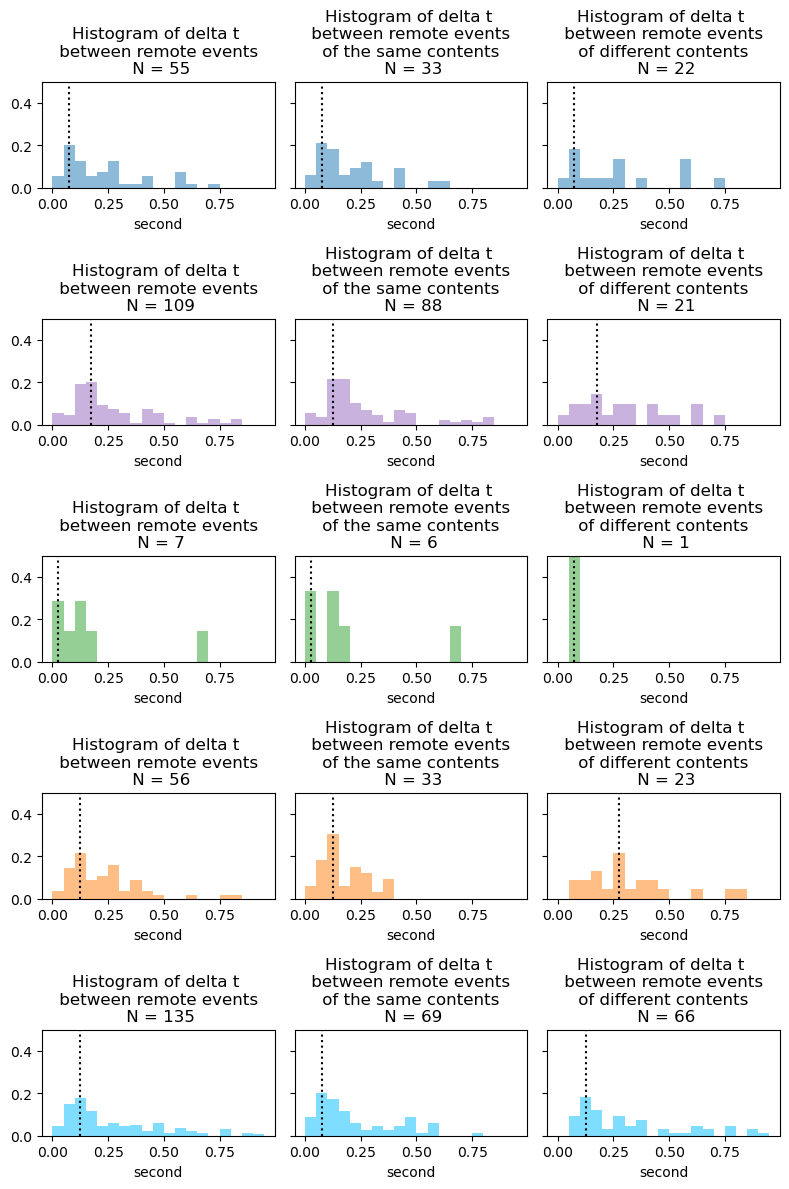

In [77]:
def return_dist_mode(count, bins, bin_width):
    return bins[np.argmax(count)] + bin_width/2
    
fig, axes = plt.subplots(5, 3, figsize=(8, 12),sharey = True)

binwidth = 0.05
bins = np.arange(0,1,binwidth)

ind = 0
for animal in ["eliot","lewis","molly","julio","klein"]:

    plot_data = np.array(delta_ts_all[animal])
    N = len(plot_data)
    count = axes[ind, 0].hist(plot_data,
             weights = np.ones_like(plot_data)/len(plot_data),
             bins = bins,
             alpha = 0.5,
             label = f"Rat {animal[0].upper()}",
              color = color_by_rat[animal]
             )
    mode = return_dist_mode(count[0], count[1], binwidth)
    axes[ind, 0].axvline(mode, linestyle = ":", color = 'k')
    
    axes[ind, 0].set_xlabel("second")
    axes[ind, 0].set_title(f"Histogram of delta t \n between remote events \n N = {N}")

    plot_data = np.array(delta_ts_same[animal])
    N = len(plot_data)
    count = axes[ind, 1].hist(plot_data,
             weights = np.ones_like(plot_data)/len(plot_data),
             bins = bins,
             alpha = 0.5,
             label = f"Rat {animal[0].upper()}",
              color = color_by_rat[animal]
             )

    mode = return_dist_mode(count[0], count[1], binwidth)
    
    axes[ind, 1].axvline(mode, linestyle = ":", color = 'k')
    axes[ind, 1].set_xlabel("second")
    axes[ind, 1].set_title(f"Histogram of delta t \n between remote events \n of the same contents \n N = {N}")

    plot_data = np.array(delta_ts_diff[animal])
    N = len(plot_data)
    count = axes[ind, 2].hist(plot_data,
             weights = np.ones_like(plot_data)/len(plot_data),
             bins = bins,
             alpha = 0.5,
             label = f"Rat {animal[0].upper()}",
              color = color_by_rat[animal]
             )
    mode = return_dist_mode(count[0], count[1], binwidth)

    axes[ind, 2].axvline(mode, linestyle = ":", color = 'k')
    axes[ind, 2].set_xlabel("second")
    axes[ind, 2].set_title(f"Histogram of delta t \n between remote events \n of different contents \n N = {N}")

    axes[ind, 0].set_ylim([0,0.5])
    axes[ind, 1].set_ylim([0,0.5])
    axes[ind, 2].set_ylim([0,0.5])

    ind += 1

plt.tight_layout()
plt.savefig(f'4L.remote_content_delta_t.pdf',dpi=300,bbox_inches='tight')

# End here

In [7]:
nwb_copy_file_name = 'lewis20240109_.nwb'
session_name = '04_Rev2Session2'

In [8]:
pandas = (ChangeofMindRemoteTheta() & {"nwb_file_name":nwb_copy_file_name,
                                           "proportion":0.1,
                                            "delta_t_minus":5,
                                            "delta_t_plus":5,
                                            "epoch":str(session_name[:2])}).fetch1("pandas")
log_df = pd.DataFrame(pandas)
log_df =log_df[log_df.has_remote_interval]

In [12]:
log_df

,timestamp_H,Home,timestamp_O,OuterWellIndex,rewardNum,change_of_mind,has_remote_interval,remote_interval,remote_content,change_of_mind_num,...,proportion_arm2,proportion_arm3,proportion_arm4,CoMNum_by_time,CoMNum_by_arm,current,future_H,future_O,past,past_reward
11,1.704833e+09,1.0,1.704833e+09,2.0,2.0,True,True,"[[1704832876.330206, 1704832876.3582058]]",[2],[0],...,0.000000,0.552658,0.000000,1,1,2.0,2.0,4.0,1.0,1.0
13,1.704833e+09,1.0,1.704833e+09,3.0,2.0,True,True,"[[1704832928.416166, 1704832928.486166], [1704...","[2, 2]","[0, 0]",...,0.111066,0.000000,0.000000,2,2,3.0,3.0,1.0,4.0,4.0
44,1.704834e+09,1.0,1.704834e+09,4.0,2.0,True,True,"[[1704833807.643492, 1704833807.699492], [1704...","[2, 2, 2, 2, 2, 4]","[0, 0, 0, 0, 0, 0]",...,0.000000,0.000000,0.000000,1,1,4.0,4.0,3.0,3.0,2.0
53,1.704834e+09,1.0,1.704834e+09,3.0,1.0,True,True,"[[1704834066.6932936, 1704834066.7332935], [17...","[3, 3, 3]","[0, 0, 0]",...,0.447172,0.000000,0.843831,2,2,3.0,3.0,4.0,2.0,2.0
63,1.704834e+09,1.0,1.704834e+09,4.0,2.0,True,True,"[[1704834343.8670812, 1704834343.891081], [170...","[4, 4, 2, 2, 2]","[0, 0, 0, 0, 0]",...,0.600784,0.000000,0.000000,3,2,4.0,4.0,1.0,3.0,2.0


In [11]:
log_df.loc[11].remote_interval

[array([1.70483288e+09, 1.70483288e+09])]

In [13]:
log_df.loc[11].remote_content

[2]